# E-Commerce Fraud Detection Dataset

E-commerce platforms noticed a strange phenomena, some transactions looked weird, for example: some cards tested with $1 purchases at midnight,
others shipped “gaming accessories” 5,000 km away.
promo codes were being reused from freshly created accounts. This dataset gathers data from online transactions and tells if each one is a fraud or not. Based on this dataset, can we predict if a transaction is a fraud?

In this notebook, we will research the E-Commerce Fraud Detection dataset from:
https://www.kaggle.com/datasets/umuttuygurr/e-commerce-fraud-detection-dataset?resource=download



## Dataset


### Importing

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [30]:
df = pd.read_csv('transactions.csv')
df.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,country,bin_country,channel,merchant_category,promo_used,avs_match,cvv_result,three_ds_flag,transaction_time,shipping_distance_km,is_fraud
0,1,1,141,47,147.93,84.75,FR,FR,web,travel,0,1,1,1,2024-01-06T04:09:39Z,370.95,0
1,2,1,141,47,147.93,107.90,FR,FR,web,travel,0,0,0,0,2024-01-09T20:13:47Z,149.62,0
2,3,1,141,47,147.93,92.36,FR,FR,app,travel,1,1,1,1,2024-01-12T06:20:11Z,164.08,0
3,4,1,141,47,147.93,112.47,FR,FR,web,fashion,0,1,1,1,2024-01-15T17:00:04Z,397.40,0
4,5,1,141,47,147.93,132.91,FR,US,web,electronics,0,1,1,1,2024-01-17T01:27:31Z,935.28,0


### Description

Those are columns types:

In [31]:
df.dtypes

,0
transaction_id,int64
user_id,int64
account_age_days,int64
total_transactions_user,int64
avg_amount_user,float64
amount,float64
country,object
bin_country,object
channel,object
merchant_category,object


So as we see, there are 299695 rows and 17 columns. Each row represents one transaction, columns represent:
- transaction_id (int) ID of the row
- user_id (int) ID of the user who made the transaction
- account_age_days (int) account age in days
- total_transactions_user (int) total of transactions made by the user
- avg_amount_user (float) avarage of all transactions' amounts of the user in dolars
- amount (float) the transaction's amount in dolars
- country (string) the user’s country
- bin_country (string) country of the card-issuing bank
- channel (string) "web" or "app"
- merchant_category (string) type of purchase: electronics, fashion, grocery, gaming, travel
- promo_used (binary) wheter discount/promo was used
- avs_match (binary) Address Verification result
- cvv_result (binary) CVV code match result
- three_ds_flag (binary) 3D Secure enabled
- transaction_time (date) Transaction timestamp (UTC)
- shipping_distance_km (float) Distance between billing and shipping addresses
- is_fraud (binary) is the transaction a fraud

Let's check if there are any null variables:

In [32]:
print(df.isna().any())

transaction_id             False
user_id                    False
account_age_days           False
total_transactions_user    False
avg_amount_user            False
amount                     False
country                    False
bin_country                False
channel                    False
merchant_category          False
promo_used                 False
avs_match                  False
cvv_result                 False
three_ds_flag              False
transaction_time           False
shipping_distance_km       False
is_fraud                   False
dtype: bool


### Data transformation

As we have a categorical variables that are not safe for our classification model to be represented as numbers (country, bin_country, merchant_category), let's make dummy variables for them:

In [33]:
df_dummy = pd.get_dummies(df, columns=['country', 'bin_country', 'merchant_category'])
df_dummy.dtypes

,0
transaction_id,int64
user_id,int64
account_age_days,int64
total_transactions_user,int64
avg_amount_user,float64
amount,float64
channel,object
promo_used,int64
avs_match,int64
cvv_result,int64


As channel takes only two values ("web" and "app") we can change them to binary (0 - web, 1 - app)


In [34]:
df_dummy = df_dummy.replace({'channel': {'web': 0, 'app': 1}})
df_dummy.head()

/tmp/ipython-input-2963894550.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_dummy = df_dummy.replace({'channel': {'web': 0, 'app': 1}})


,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,channel,promo_used,avs_match,cvv_result,...,bin_country_NL,bin_country_PL,bin_country_RO,bin_country_TR,bin_country_US,merchant_category_electronics,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel
0,1,1,141,47,147.93,84.75,0,0,1,1,...,False,False,False,False,False,False,False,False,False,True
1,2,1,141,47,147.93,107.90,0,0,0,0,...,False,False,False,False,False,False,False,False,False,True
2,3,1,141,47,147.93,92.36,1,1,1,1,...,False,False,False,False,False,False,False,False,False,True
3,4,1,141,47,147.93,112.47,0,0,1,1,...,False,False,False,False,False,False,True,False,False,False
4,5,1,141,47,147.93,132.91,0,0,1,1,...,False,False,False,False,True,True,False,False,False,False


Next, as the date format is not readable for programme, let's divide it into: year, month, day, hour, we do not need exact minute or second

In [35]:
df_dummy['year'] = df['transaction_time'].str.split('-').str[0]
df_dummy['month'] = df['transaction_time'].str.split('-').str[1]
df_dummy['day'] = df['transaction_time'].str.split('-').str[2].str.split('T').str[0]
df_dummy['hour'] = df['transaction_time'].str.split('-').str[2].str.split('T').str[1].str.split(':').str[0]
df_dummy = df_dummy.drop('transaction_time', axis=1)
df_dummy.head()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,channel,promo_used,avs_match,cvv_result,...,bin_country_US,merchant_category_electronics,merchant_category_fashion,merchant_category_gaming,merchant_category_grocery,merchant_category_travel,year,month,day,hour
0,1,1,141,47,147.93,84.75,0,0,1,1,...,False,False,False,False,False,True,2024,01,06,04
1,2,1,141,47,147.93,107.90,0,0,0,0,...,False,False,False,False,False,True,2024,01,09,20
2,3,1,141,47,147.93,92.36,1,1,1,1,...,False,False,False,False,False,True,2024,01,12,06
3,4,1,141,47,147.93,112.47,0,0,1,1,...,False,False,True,False,False,False,2024,01,15,17
4,5,1,141,47,147.93,132.91,0,0,1,1,...,True,True,False,False,False,False,2024,01,17,01


In [36]:
df_dummy['year'].describe()

,year
count,299695
unique,1
top,2024
freq,299695


In [37]:
df_dummy = df_dummy.drop('year', axis=1)

As the data is only from 2024, we can drop the year column

## Analysis

### Brief description

In [38]:
df.describe()

,transaction_id,user_id,account_age_days,total_transactions_user,avg_amount_user,amount,promo_used,avs_match,cvv_result,three_ds_flag,shipping_distance_km,is_fraud
count,299695.0000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000,299695.000000
mean,149848.0000,3002.559432,973.397871,50.673321,148.142973,177.165279,0.153640,0.837999,0.872110,0.784588,357.049028,0.022062
std,86514.6388,1732.309663,525.241409,5.976391,200.364624,306.926507,0.360603,0.368453,0.333968,0.411109,427.672074,0.146887
min,1.0000,1.000000,1.000000,40.000000,3.520000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,74924.5000,1501.000000,516.000000,46.000000,46.190000,42.100000,0.000000,1.000000,1.000000,1.000000,136.600000,0.000000
50%,149848.0000,3007.000000,975.000000,51.000000,90.130000,89.990000,0.000000,1.000000,1.000000,1.000000,273.020000,0.000000
75%,224771.5000,4504.000000,1425.000000,56.000000,173.450000,191.110000,0.000000,1.000000,1.000000,1.000000,409.180000,0.000000
max,299695.0000,6000.000000,1890.000000,60.000000,4565.290000,16994.740000,1.000000,1.000000,1.000000,1.000000,3748.560000,1.000000


Let's see how variables correlate with each other

### Correlation analysis

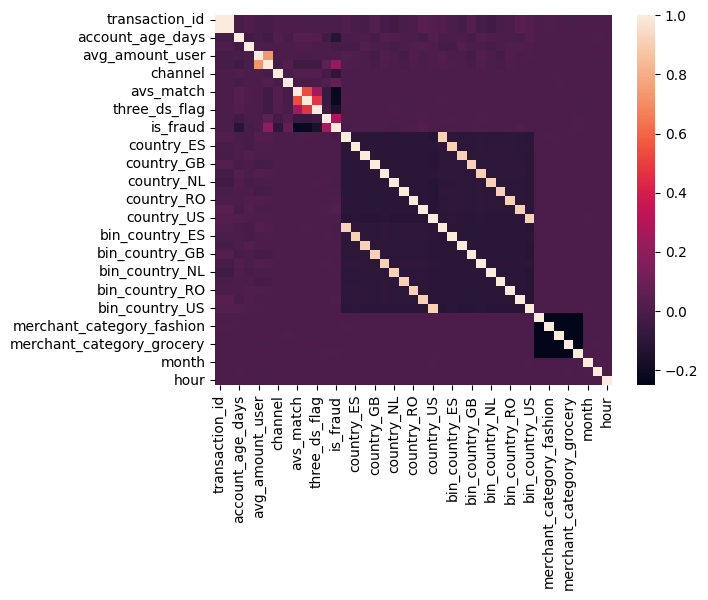

In [39]:
sns.heatmap(df_dummy.corr())
plt.show()

As we can see, there are no interesting correlaions for the countries, bin_countries, categories, month and hour, so let's shorten our chart to the more important ones. We can also drop transaction id and user id as calculating its correlation does not have any sense

The only thing that we can observe in the rejected values correlations is that there are negative correlations between one country and another country in bin_country, so we can assume that more transactions are intranational. Before we drop those values, let's add the international column to the dataset. It will be 0 if the transaction is intranational and 1 if international

In [40]:
df_dummy['international'] = (df['country'] == df['bin_country'])

:Now let's see the correlations with international

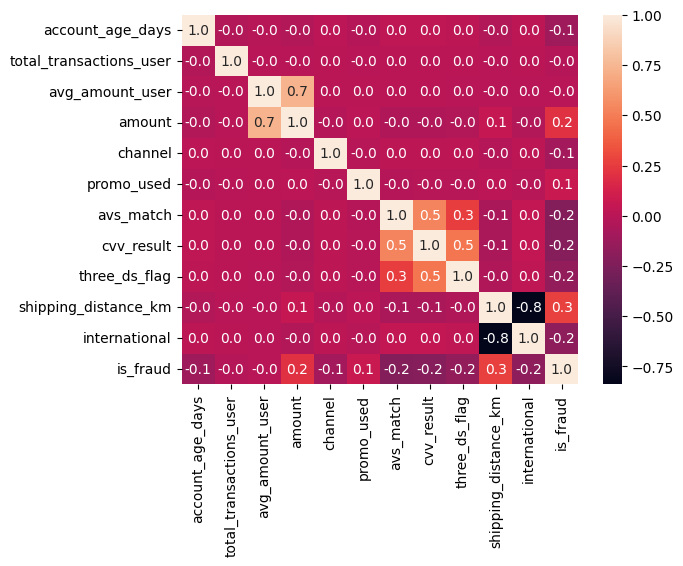

In [41]:
df_short = df_dummy[[	'account_age_days',	'total_transactions_user',
              'avg_amount_user',	'amount',	'channel', 'promo_used',	'avs_match', 'cvv_result',
              'three_ds_flag',	'shipping_distance_km',	'international', 'is_fraud']]
sns.heatmap(df_short.corr(), annot=True, fmt='.1f')
plt.show()

Fraud correlates weakly with account age, transaction amount, channel (web), promo_used, avs_match, cvv_result, three_ds_flag, international and moderately with shipping distance

We can see strong corelation between avs_match, cvv_result and three_ds_flag  

### Charts

In [42]:
non_fraud = df_short[df_short['is_fraud'] == 0]
fraud = df_short[df_short['is_fraud'] == 1]

<Axes: title={'center': 'shipping_distance_km'}, xlabel='is_fraud'>

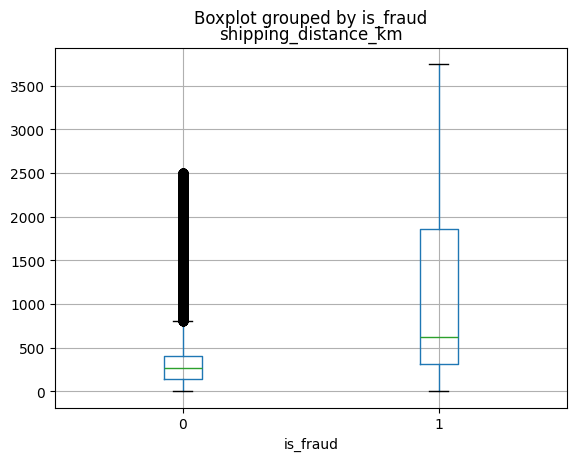

In [43]:
df_short.boxplot(column = ['shipping_distance_km'], by='is_fraud')

<Axes: title={'center': 'amount'}, xlabel='is_fraud'>

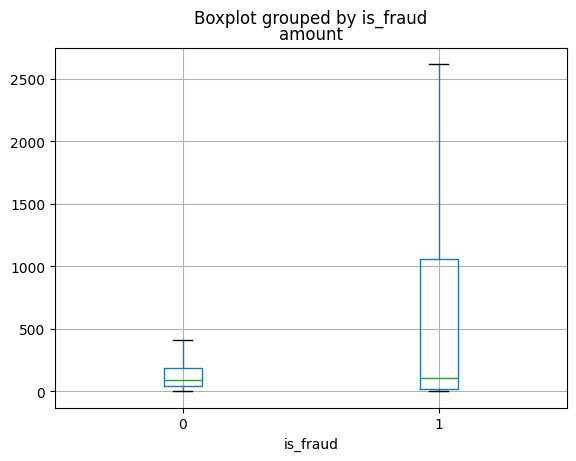

In [44]:
df_short.boxplot(column = ['amount'], by='is_fraud', showfliers=False)

<Axes: title={'center': 'account_age_days'}, xlabel='is_fraud'>

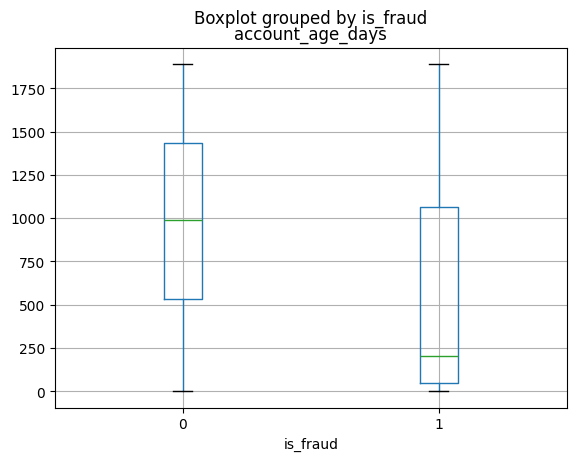

In [45]:
df_short.boxplot(column = ['account_age_days'], by='is_fraud')

In [46]:
def plot_fraud_and_non_fraud(column):
  fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
  ax1.pie(non_fraud[column].value_counts(), autopct='%1.1f%%',labels=['True', 'False'])
  ax1.set_title(f"Non-fraud {column}")
  ax2.pie(fraud[column].value_counts(), autopct='%1.1f%%', labels=['True', 'False'])
  ax2.set_title(f"Fraud {column}")
  plt.show()


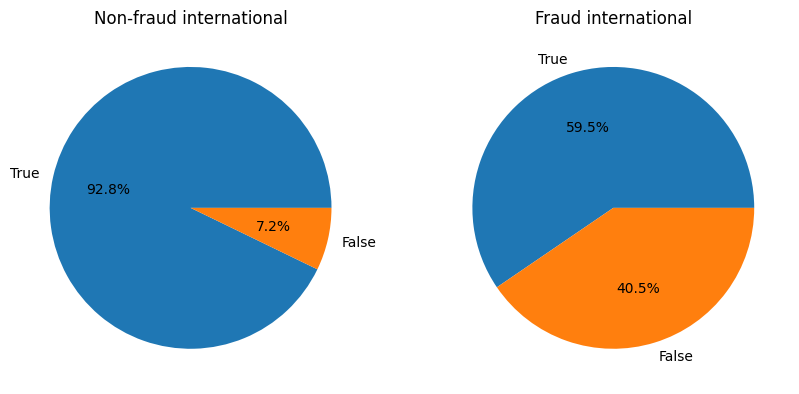

In [47]:
plot_fraud_and_non_fraud('international')

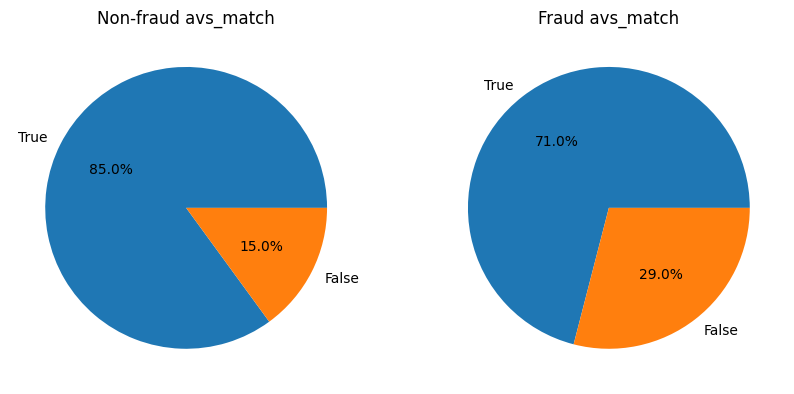

In [48]:
plot_fraud_and_non_fraud('avs_match')

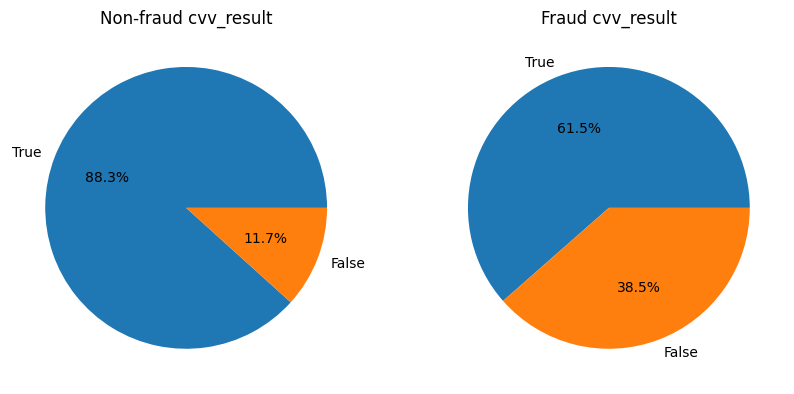

In [49]:
plot_fraud_and_non_fraud('cvv_result')

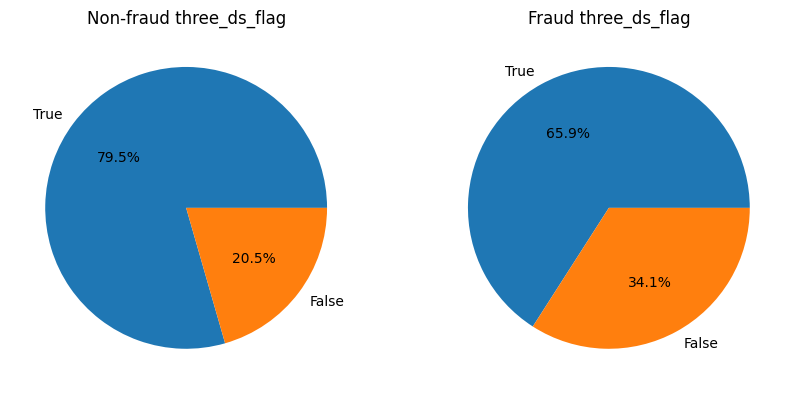

In [50]:
plot_fraud_and_non_fraud('three_ds_flag')

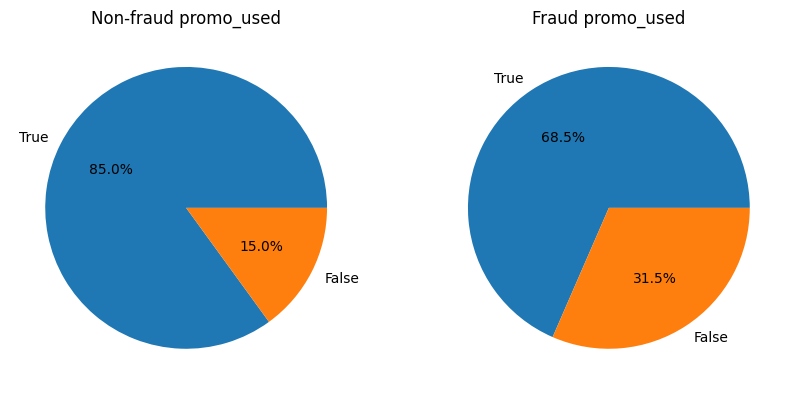

In [51]:
plot_fraud_and_non_fraud('promo_used')

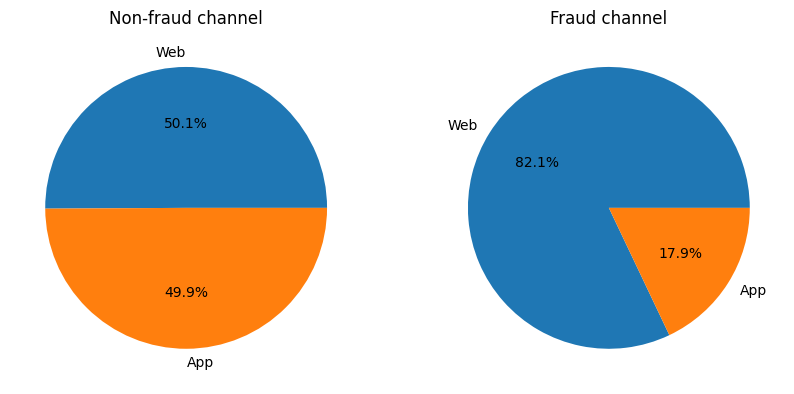

In [52]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))
ax1.pie(non_fraud['channel'].value_counts(), autopct='%1.1f%%',labels=['Web', 'App'])
ax1.set_title("Non-fraud channel")
ax2.pie(fraud['channel'].value_counts(), autopct='%1.1f%%', labels=['Web', 'App'])
ax2.set_title("Fraud channel")
plt.show()

## Training the model

Before training any model, let's split the data into: training and test

In [53]:
from sklearn.model_selection import train_test_split

In [54]:
x = df_short[['account_age_days', 'avg_amount_user',	'amount',	'channel', 'promo_used',	'avs_match', 'cvv_result',
              'three_ds_flag',	'shipping_distance_km',	'international',]]
y = df_short['is_fraud']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

### Logistic regression

Let's firstly try the classical logistic regression

In [55]:
from sklearn.linear_model import LogisticRegression

In [56]:
model = LogisticRegression()
model.fit(x_train, y_train)
predicted = model.predict(x_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [57]:
model.score(x_test, y_test)

0.9855186911210224

This score is actually high enough but let's check other models

### K-nearest neighbour

Let's check how k-nearest neighbour model will perform on different amount of neighbours

In [59]:
from sklearn.neighbors import KNeighborsClassifier


In [64]:
scores = []
for i in range(1, 5):
  model = KNeighborsClassifier(n_neighbors=i)
  model.fit(x_train, y_train)
  prediction = model.predict(x_test)
  scores.append(model.score(x_test, y_test))

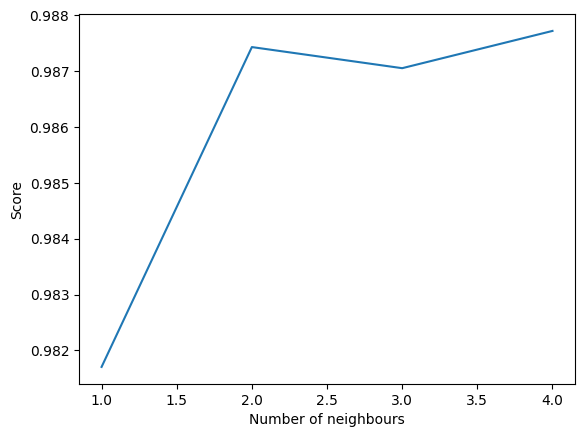

In [65]:
plt.plot(range(1, 5), scores)
plt.xlabel("Number of neighbours")
plt.ylabel("Score")
plt.show()

As we see, the K-nearest neighbour for 3 neighbours is a bit better than logistic regression

### AdaBoost

In [66]:
from sklearn.ensemble import AdaBoostClassifier


In [67]:
model = AdaBoostClassifier()
model.fit(x_train, y_train)
prediction = model.predict(x_test)
model.score(x_test, y_test)

0.9905682412216797